# 02_itens_eda — Análise de Itens por Cliente

**Objetivo:** identificar sinais de churn no nível de item.

O cliente levantou uma hipótese importante: antes de sumir por completo, o cliente começa a **reduzir progressivamente o volume de itens específicos** — sinal de migração gradual para um concorrente.

Este notebook constrói features no nível `cliente × item × mês` para capturar esse padrão.

---

### Features construídas

| Feature | Descrição |
|---|---|
| `n_itens_distintos` | Quantos itens diferentes o cliente pediu no mês |
| `tendencia_slope` | Inclinação da regressão linear da quantidade por item |
| `var_pct_ultimo` | Variação percentual de quantidade no último mês |
| `qtd_media` | Quantidade média histórica do item para o cliente |
| `qtd_ultimo_mes` | Quantidade pedida no último mês ativo |
| `n_meses_ativo` | Meses em que o par cliente × item teve pedido |

> **YoY descartado:** teste de Kruskal-Wallis mostrou que apenas 1.6% dos pares têm sazonalidade significativa — não justifica a complexidade.

### Output
- `data/processed/cliente_item_tendencia.parquet` — um registro por `cliente × item`

In [5]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_REF     = pd.Timestamp("2026-05-01")
INICIO       = "2023-01-01"
VERDE        = ["#d8f3dc", "#b7e4c7", "#95d5b2", "#74c69d",
                "#52b788", "#40916c", "#2d6a4f", "#1b4332"]

PROJECT_ROOT = Path(r"C:\Users\carva\central_eto")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("DATA_REF:", DATA_REF.date())

Working directory: C:\Users\carva\central_eto
DATA_REF: 2026-05-01


---
## Seção 1 — Busca de Dados

Carregamos `df_base` do banco (a mesma query usada no notebook 01) e os parquets gerados anteriormente para cruzar com RED_FLAG.

In [6]:
from src import db

sql = Path("queries/base_pedidos.sql").read_text()
df_base = db.get_data(sql)

print(f"df_base bruto: {df_base.shape}")
df_base.head(3)

C:\Users\carva\central_eto\src\db.py:40: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, cn, params=params)


df_base bruto: (535660, 6)


,CLIENTE,SERVICO,SETOR,DATA_ENTRADA,VL_SERVICO,NRO_PED
0,903,SERVIÇO DE PROCESSAMENTO E ESTERILIZAÇÃO,CME,2024-07-06,0.00,0119925
1,37,CABO PARA MOTOR,GUSTAVO AQUINO,2021-05-03,24.25,25026
2,37,BISTURI ELÉTRICO (CABO+CANETA+PONTA),GUSTAVO AQUINO,2021-05-03,0.00,25026


In [7]:
# Filtrar janela 2023+ e clientes ativos (os mesmos 763 do notebook 01)
df_base["DATA_ENTRADA"] = pd.to_datetime(df_base["DATA_ENTRADA"], errors="coerce")
df_base["ANO_MES"]      = df_base["DATA_ENTRADA"].dt.to_period("M")

# Clipes de negativos — mesma política do notebook 01
df_base["VL_SERVICO"] = df_base["VL_SERVICO"].clip(lower=0)

df = df_base[df_base["DATA_ENTRADA"] >= INICIO].copy()

print(f"Após filtro 2023+: {df.shape}")
print(f"Clientes distintos: {df['CLIENTE'].nunique()}")
print(f"Itens distintos   : {df['SERVICO'].nunique()}")

Após filtro 2023+: (363834, 7)
Clientes distintos: 765
Itens distintos   : 1537


In [8]:
# Carregar RED_FLAG e categoria do parquet gerado pelo notebook 01
cliente_fidelidade = pd.read_parquet("data/processed/cliente_fidelidade.parquet")
red_flag_map = cliente_fidelidade.set_index("CLIENTE")[["RED_FLAG", "categoria_cliente"]]

print(f"Clientes no parquet: {len(red_flag_map)}")
print(f"Com RED_FLAG: {red_flag_map['RED_FLAG'].sum()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/cliente_fidelidade.parquet'

---
## Seção 2 — EDA de Itens

Antes de construir as features, vamos entender o dado: quantos itens distintos existem, como se distribuem, quais são os mais frequentes.

In [ ]:
# Distribuição de itens distintos por cliente (desde 2023)
itens_por_cliente = (
    df.groupby("CLIENTE")["SERVICO"]
    .nunique()
    .rename("n_itens_distintos_total")
    .reset_index()
)

print("Itens distintos por cliente (histórico completo 2023+):")
print(itens_por_cliente["n_itens_distintos_total"].describe().round(1))

Itens distintos por cliente (histórico completo 2023+):
count    764.0
mean      17.0
std       29.8
min        1.0
25%        3.0
50%        9.0
75%       18.0
max      512.0
Name: n_itens_distintos_total, dtype: float64


In [ ]:
# Todos os itens distintos, quantos clientes usam cada um
itens_distintos = (
    df.groupby("SERVICO")["CLIENTE"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"CLIENTE": "n_clientes"})
)

print(f"Total de itens distintos: {len(itens_distintos)}")
#with pd.option_context("display.max_rows", 2000):
    #display(itens_distintos)



Total de itens distintos: 1536


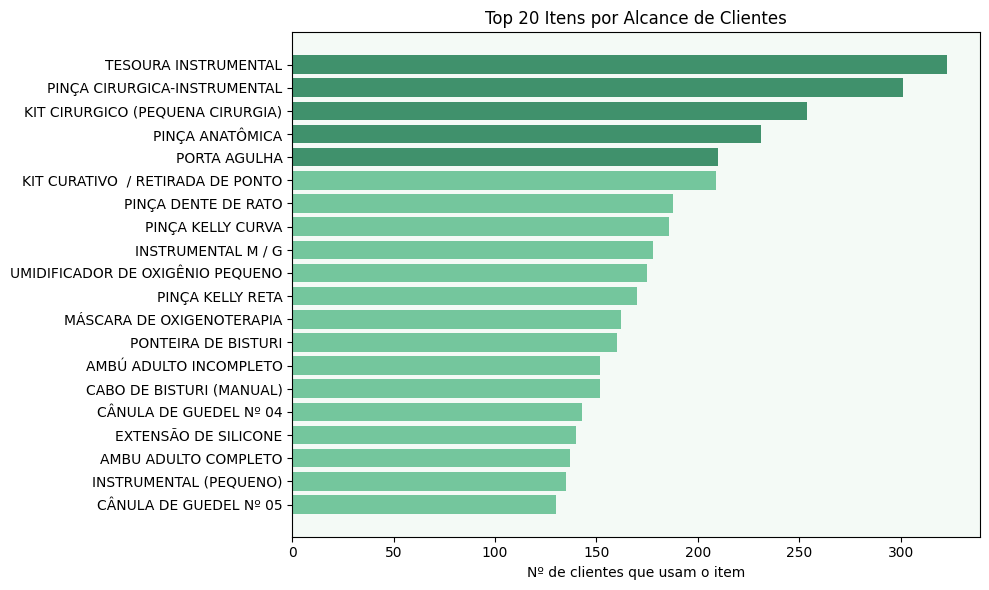

,SERVICO,n_clientes
0,TESOURA INSTRUMENTAL,323
1,PINÇA CIRURGICA-INSTRUMENTAL,301
2,KIT CIRURGICO (PEQUENA CIRURGIA),254
3,PINÇA ANATÔMICA,231
4,PORTA AGULHA,210
5,KIT CURATIVO / RETIRADA DE PONTO,209
6,PINÇA DENTE DE RATO,188
7,PINÇA KELLY CURVA,186
8,INSTRUMENTAL M / G,178
9,UMIDIFICADOR DE OXIGÊNIO PEQUENO,175


In [ ]:
# Os 20 itens mais pedidos (por número de clientes que os usam)
top_itens = (
    df.groupby("SERVICO")["CLIENTE"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={"CLIENTE": "n_clientes"})
)

fig, ax = plt.subplots(figsize=(10, 6))
cores = [VERDE[5] if i < 5 else VERDE[3] for i in range(len(top_itens))]
ax.barh(top_itens["SERVICO"][::-1], top_itens["n_clientes"][::-1], color=cores[::-1])
ax.set_xlabel("Nº de clientes que usam o item")
ax.set_title("Top 20 Itens por Alcance de Clientes")
ax.set_facecolor("#f4faf6")
plt.tight_layout()
plt.show()

display(top_itens)

---
## Seção 3 — Agregação cliente × item × mês

Granularidade central deste notebook. Para cada combinação `(CLIENTE, SERVICO, ANO_MES)` calculamos quantidade e valor.

> **Por que quantidade = count de linhas?** O banco registra uma linha por unidade de item. Então `count` captura o volume físico pedido.

In [ ]:
cliente_item_mes = (
    df.groupby(["CLIENTE", "SERVICO", "ANO_MES"])
    .agg(
        qtd=("VL_SERVICO", "count"),    # unidades pedidas
        valor=("VL_SERVICO", "sum"),    # valor total do item no mês
    )
    .reset_index()
)

print(f"Shape: {cliente_item_mes.shape}")
print(f"Combinações cliente × item: {cliente_item_mes.groupby(['CLIENTE','SERVICO']).ngroups:,}")
cliente_item_mes.head()

Shape: (78266, 5)
Combinações cliente × item: 12,967


,CLIENTE,SERVICO,ANO_MES,qtd,valor
0,1,AFASTADOR CIRURGICO GRANDE,2023-01,5,158.34
1,1,AFASTADOR CIRURGICO GRANDE,2023-02,3,90.48
2,1,AFASTADOR CIRURGICO GRANDE,2023-03,7,158.34
3,1,AFASTADOR CIRURGICO GRANDE,2023-04,7,203.74
4,1,AFASTADOR CIRURGICO GRANDE,2023-05,3,67.98


Vamos fazer uma analise simples para melhor entender a tabela

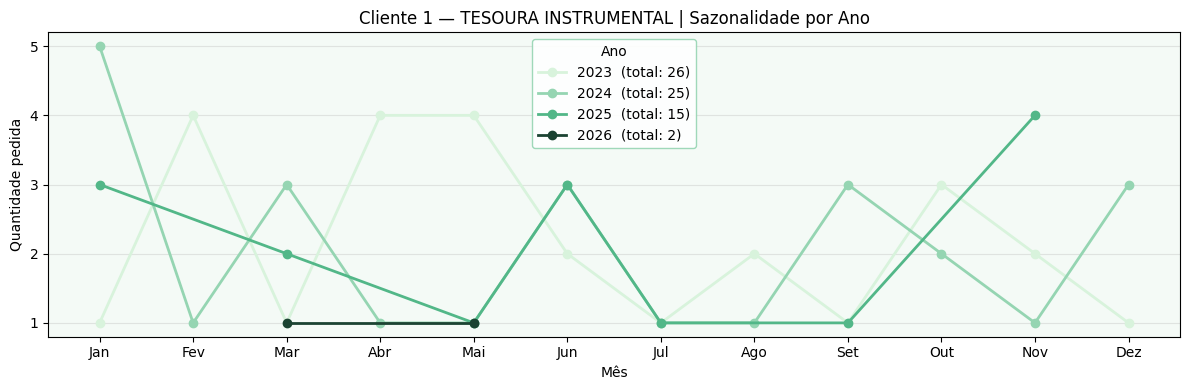

In [ ]:
sub = cliente_item_mes[
    (cliente_item_mes["CLIENTE"] == 1) &
    (cliente_item_mes["SERVICO"].str.strip() == "TESOURA INSTRUMENTAL")
].copy()

sub["ANO"] = sub["ANO_MES"].dt.year
sub["MES"] = sub["ANO_MES"].dt.month

MESES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

anos = sorted(sub["ANO"].unique())
indices = [int(i) for i in np.linspace(0, len(VERDE) - 1, len(anos))]
cores_ano = {ano: VERDE[idx] for ano, idx in zip(anos, indices)}
totais_ano = sub.groupby("ANO")["qtd"].sum()

fig, ax = plt.subplots(figsize=(12, 4))

for ano, grupo in sub.groupby("ANO"):
    total = int(totais_ano[ano])
    ax.plot(
        grupo["MES"], grupo["qtd"],
        marker="o", linewidth=2, markersize=6,
        label=f"{ano}  (total: {total})",
        color=cores_ano.get(ano, "gray")
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_title("Cliente 1 — TESOURA INSTRUMENTAL | Sazonalidade por Ano")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade pedida")
ax.legend(title="Ano", framealpha=0.9, edgecolor="#95d5b2")
ax.set_facecolor("#f4faf6")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()


Aqui podemos ver que na janela temporal o cliente 1 diminuiu a esterilizacao de tesouras instrumentais. Talvez isso possa indicar que temos um outro fornecedor mais barato.

Aparentemente temos uma sazonalidade, padroes mensais ao longo do ano. Vamos aplicar o teste de kruskal (os grupos - meses- sao significativamente diferentes entre si, ou a variacao e somente ruido aleatorio) para checar se ha ou nao. 

In [ ]:
from scipy.stats import kruskal

def tem_sazonalidade(grupo):
    meses = [g["qtd"].values for _, g in grupo.groupby("MES")]
    meses_validos = [m for m in meses if len(m) >= 2]
    if len(meses_validos) < 3:
        return np.nan
    stat, p = kruskal(*meses_validos)
    return p < 0.05

# Adiciona coluna MES para o teste (se não existir)
cim = cliente_item_mes.copy()
cim["MES"] = cim["ANO_MES"].dt.month

sazonalidade = (
    cim.groupby(["CLIENTE", "SERVICO"])
    .apply(tem_sazonalidade)
    .reset_index(name="tem_sazonalidade")
)

n_total     = sazonalidade["tem_sazonalidade"].notna().sum()
n_sazonal   = sazonalidade["tem_sazonalidade"].sum()
n_sem       = n_total - n_sazonal
n_sem_dados = sazonalidade["tem_sazonalidade"].isna().sum()

print(f"Pares testados          : {n_total:,}")
print(f"  Com sazonalidade      : {n_sazonal:,}  ({n_sazonal/n_total:.1%})")
print(f"  Sem sazonalidade      : {n_sem:,}  ({n_sem/n_total:.1%})")
print(f"Pares sem dados p/ testar: {n_sem_dados:,}")


c:\Users\carva\central_eto\.venv\Lib\site-packages\scipy\stats\_stats_py.py:8492: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


Pares testados          : 1,916
  Com sazonalidade      : 32  (1.7%)
  Sem sazonalidade      : 1,884  (98.3%)
Pares sem dados p/ testar: 11,051


Não sabemos se esses 11.048 pares têm sazonalidade, porque não havia dados suficientes para testar. Entao nao vamos incluir a sazonalidade.

---
## Seção 4 — Feature: n_itens_distintos por mês

**Hipótese:** quando um cliente começa a sumir, ele primeiro reduz o *portfólio* — para de pedir alguns itens antes de parar completamente. Isso se manifesta como queda em `n_itens_distintos`.

Vamos verificar se clientes com RED_FLAG têm portfólio menor no último mês ativo.

In [ ]:
# n_itens_distintos por cliente por mês
n_itens_mes = (
    df.groupby(["CLIENTE", "ANO_MES"])["SERVICO"]
    .nunique()
    .reset_index(name="n_itens_distintos")
)

display(n_itens_mes.head(12))
print(n_itens_mes["n_itens_distintos"].describe().round(1))


,CLIENTE,ANO_MES,n_itens_distintos
0,1,2023-01,102
1,1,2023-02,92
2,1,2023-03,82
3,1,2023-04,88
4,1,2023-05,78
5,1,2023-06,87
6,1,2023-07,86
7,1,2023-08,82
8,1,2023-09,93
9,1,2023-10,88


count    9914.0
mean        7.9
std        17.9
min         1.0
25%         2.0
50%         4.0
75%         8.0
max       353.0
Name: n_itens_distintos, dtype: float64


---
## Seção 5 — Feature: Tendência Linear por Item

**O que é:** para cada par `(cliente, item)`, ajustamos uma reta nos últimos meses de quantidade pedida. A inclinação (`slope`) indica se o volume está crescendo (positivo) ou caindo (negativo).

**Por que `np.polyfit`?** É a função padrão para regressão polinomial em numpy. Com grau 1 (`deg=1`), ela retorna os coeficientes `[slope, intercept]` — usamos só o `slope`.

> Exemplo: slope = -0.5 significa que, em média, o cliente pediu 0,5 unidade a menos por mês desse item.

In [ ]:
def tendencia_slope(series):
    """Retorna a inclinação da tendência linear. NaN se < 2 pontos."""
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    x = np.arange(len(s))
    slope, _ = np.polyfit(x, s.values, 1)
    return slope

# Ordenar por tempo antes de calcular
cliente_item_mes = cliente_item_mes.sort_values(["CLIENTE", "SERVICO", "ANO_MES"])

tendencias = (
    cliente_item_mes
    .groupby(["CLIENTE", "SERVICO"])["qtd"]
    .apply(tendencia_slope)
    .reset_index(name="tendencia_slope")
)

print(f"Combinações calculadas: {len(tendencias):,}")
print("\nDistribuição dos slopes:")
print(tendencias["tendencia_slope"].describe().round(3))

Combinações calculadas: 12,967

Distribuição dos slopes:
count    7972.000
mean       -0.037
std         0.681
min       -14.500
25%        -0.024
50%        -0.000
75%         0.005
max        17.000
Name: tendencia_slope, dtype: float64


Das 12967 combinacoes. 7972 sao as que possuem pelo menos dois pontos - cliente mes item - 

Mean = -0.042
A tendência média geral é levemente negativa — em média, os itens perdem 0.04 unidades por mês. Quase zero, então a base como um todo é estável.

Std = 0.675
O desvio padrão é muito maior que a média. Isso significa que há muita variação entre os pares — alguns caindo forte, outros crescendo forte — mas quando você faz a média de todos, eles quase se cancelam.

Min = -14.5 / Max = 17
Esses são casos extremos — provavelmente clientes premium com volumes altíssimos. Uma queda de 14 unidades por mês em um item é enorme, mas se o cliente pede 100 unidades/mês, é diferente de um que pede 5. Vale investigar quem é.

25% = -0.027
75% dos pares têm slope acima de -0.027 — ou seja, a grande maioria está estável ou crescendo. Só 25% têm queda mais acentuada que isso.

50% = -0.000
A mediana é praticamente zero. Isso quer dizer que metade dos pares está estável ou crescendo e metade está caindo — mas a maioria das quedas é muito pequena (próxima de zero).

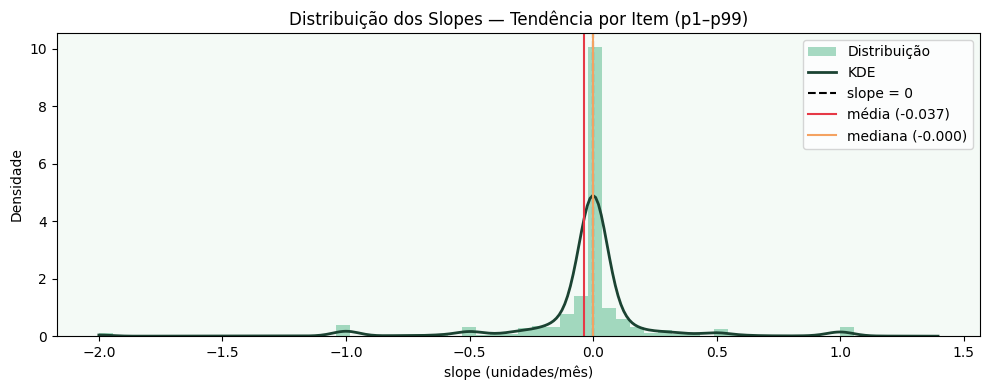

In [ ]:
p1  = tendencias["tendencia_slope"].quantile(0.01)
p99 = tendencias["tendencia_slope"].quantile(0.99)

data = tendencias["tendencia_slope"].dropna()
data_clip = data[(data >= p1) & (data <= p99)]

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(data_clip, bins=60, density=True, color="#52b788", alpha=0.5, label="Distribuição")

# curva KDE (o "sino")
from scipy.stats import gaussian_kde
kde = gaussian_kde(data_clip)
x = np.linspace(p1, p99, 300)
ax.plot(x, kde(x), color="#1b4332", linewidth=2, label="KDE")

ax.axvline(0,                    color="black",   lw=1.5, ls="--", label="slope = 0")
ax.axvline(data.mean(),          color="#e63946", lw=1.5, ls="-",  label=f"média ({data.mean():.3f})")
ax.axvline(data.median(),        color="#f4a261", lw=1.5, ls="-",  label=f"mediana ({data.median():.3f})")

ax.set_title("Distribuição dos Slopes — Tendência por Item (p1–p99)")
ax.set_xlabel("slope (unidades/mês)")
ax.set_ylabel("Densidade")
ax.legend()
ax.set_facecolor("#f4faf6")
plt.tight_layout()
plt.show()


In [ ]:
data_extremos = data[(data <= -0.5) | (data >= 0.5)]

print(f"Em queda acentuada (≤ -0.5): {(data <= -0.5).sum()} pares")
print(f"Em crescimento acentuado (≥ +0.5): {(data >= 0.5).sum()} pares")


Em queda acentuada (≤ -0.5): 540 pares
Em crescimento acentuado (≥ +0.5): 340 pares


---
## Seção 6 — Feature: Variação Percentual mês a mês

O slope captura a tendência geral. A variação percentual (`pct_change`) captura o **choque recente** — uma queda brusca no último mês é um sinal diferente de uma queda gradual.

> Testamos sazonalidade via Kruskal-Wallis: apenas 1.6% dos pares têm sazonalidade significativa. YoY não se justifica como feature geral.

In [ ]:
# Variação percentual de quantidade mês a mês, por cliente × item
cliente_item_mes["var_pct"] = (
    cliente_item_mes
    .groupby(["CLIENTE", "SERVICO"])["qtd"]
    .pct_change()
)

# Variação no último mês disponível por cliente × item
var_ultimo = (
    cliente_item_mes
    .sort_values(["CLIENTE", "SERVICO", "ANO_MES"])
    .groupby(["CLIENTE", "SERVICO"])
    .agg(
        var_pct_ultimo=("var_pct", "last"),
        qtd_ultimo_mes=("qtd",     "last"),
        qtd_media=("qtd",          "mean"),
        n_meses_ativo=("ANO_MES",  "count"),
    )
    .reset_index()
)

print("Variação % no último mês (sem outliers extremos):")
p1, p99 = var_ultimo["var_pct_ultimo"].quantile([0.01, 0.99])
print(var_ultimo[var_ultimo["var_pct_ultimo"].between(p1, p99)]["var_pct_ultimo"].describe().round(2))

Variação % no último mês (sem outliers extremos):
count    7824.00
mean        0.02
std         0.47
min        -0.80
25%         0.00
50%         0.00
75%         0.00
max         2.00
Name: var_pct_ultimo, dtype: float64


---
## Seção 7 — Consolidação: cliente_item_tendencia

Juntamos tudo em uma tabela por `cliente × item`, com todas as features de tendência.

In [ ]:
cliente_item_tendencia = (
    var_ultimo
    .merge(tendencias, on=["CLIENTE", "SERVICO"], how="left")
    .join(red_flag_map, on="CLIENTE")
)

print(f"Shape: {cliente_item_tendencia.shape}")
print(f"Colunas: {list(cliente_item_tendencia.columns)}")
cliente_item_tendencia.head()

Shape: (12967, 9)
Colunas: ['CLIENTE', 'SERVICO', 'var_pct_ultimo', 'qtd_ultimo_mes', 'qtd_media', 'n_meses_ativo', 'tendencia_slope', 'RED_FLAG', 'categoria_cliente']


,CLIENTE,SERVICO,var_pct_ultimo,qtd_ultimo_mes,qtd_media,n_meses_ativo,tendencia_slope,RED_FLAG,categoria_cliente
0,1,AFASTADOR CIRURGICO GRANDE,0.000000,2,3.837838,37,-7.586534e-03,False,premium
1,1,AFASTADOR CIRURGICO MÉDIO,-0.666667,1,3.647059,34,-4.216960e-02,False,premium
2,1,AFASTADOR CIRURGICO PEQUENO,0.000000,1,1.400000,15,5.714286e-02,False,premium
3,1,AFASTADOR DE DOYEN,-0.833333,1,3.171429,35,-7.002801e-03,False,premium
4,1,AMBU ADULTO COMPLETO,-0.500000,1,1.333333,3,1.101153e-16,False,premium


---
## Seção 8 — EDA: Quem está caindo?

Agora que temos as features, vamos explorar os padrões:
- Itens com queda em mais clientes
- Clientes com maior queda de portfólio
- Slope vs RED_FLAG

=== tendencia_slope × RED_FLAG ===
           count   mean    std   min    25%  50%    75%   max
RED_FLAG                                                     
False     6223.0 -0.036  0.690 -14.5 -0.024 -0.0  0.007  17.0
True      1749.0 -0.039  0.647  -8.0 -0.023 -0.0  0.000   7.0


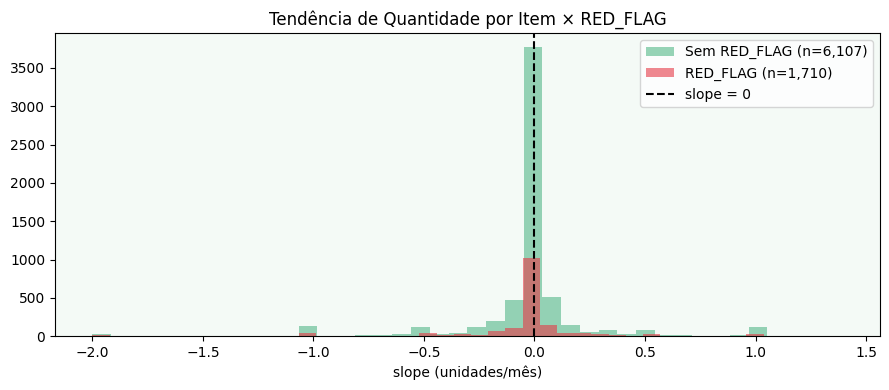

In [ ]:
# Slope médio × RED_FLAG — clientes em risco têm tendência mais negativa?
print("=== tendencia_slope × RED_FLAG ===")
print(
    cliente_item_tendencia
    .groupby("RED_FLAG")["tendencia_slope"]
    .describe().round(3)
)

fig, ax = plt.subplots(figsize=(9, 4))
p1, p99 = cliente_item_tendencia["tendencia_slope"].quantile([0.01, 0.99])
for flag, label, color in [
    (False, "Sem RED_FLAG", "#52b788"),
    (True,  "RED_FLAG",     "#e63946"),
]:
    data = (
        cliente_item_tendencia[
            (cliente_item_tendencia["RED_FLAG"] == flag) &
            (cliente_item_tendencia["tendencia_slope"].between(p1, p99))
        ]["tendencia_slope"]
    )
    ax.hist(data, bins=40, alpha=0.6, label=f"{label} (n={len(data):,})", color=color)

ax.axvline(0, color="black", lw=1.5, ls="--", label="slope = 0")
ax.set_title("Tendência de Quantidade por Item × RED_FLAG")
ax.set_xlabel("slope (unidades/mês)")
ax.legend()
ax.set_facecolor("#f4faf6")
plt.tight_layout()
plt.show()

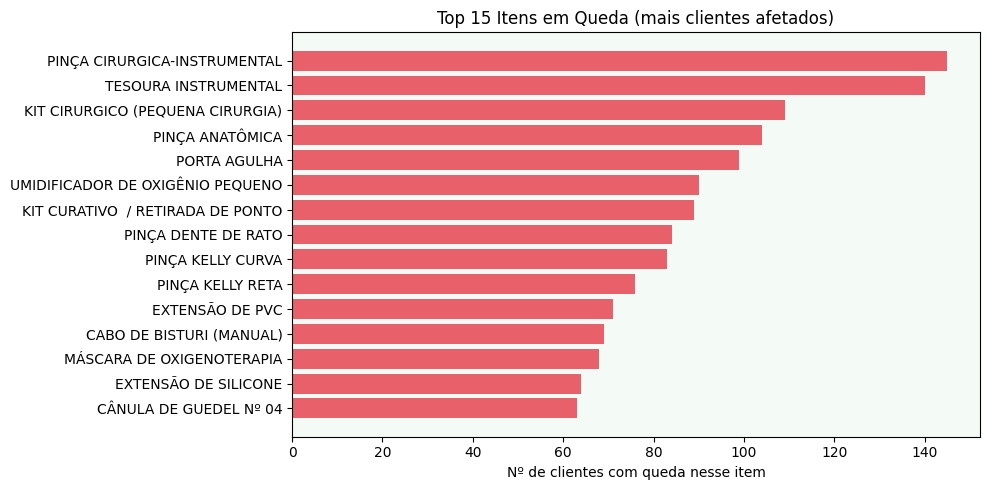

,SERVICO,n_clientes_em_queda
0,PINÇA CIRURGICA-INSTRUMENTAL,145
1,TESOURA INSTRUMENTAL,140
2,KIT CIRURGICO (PEQUENA CIRURGIA),109
3,PINÇA ANATÔMICA,104
4,PORTA AGULHA,99
5,UMIDIFICADOR DE OXIGÊNIO PEQUENO,90
6,KIT CURATIVO / RETIRADA DE PONTO,89
7,PINÇA DENTE DE RATO,84
8,PINÇA KELLY CURVA,83
9,PINÇA KELLY RETA,76


In [ ]:
# Itens com maior nº de clientes em queda (slope < 0)
itens_queda = (
    cliente_item_tendencia[cliente_item_tendencia["tendencia_slope"] < 0]
    .groupby("SERVICO")["CLIENTE"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"CLIENTE": "n_clientes_em_queda"})
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(itens_queda["SERVICO"][::-1], itens_queda["n_clientes_em_queda"][::-1], color="#e63946", alpha=0.8)
ax.set_xlabel("Nº de clientes com queda nesse item")
ax.set_title("Top 15 Itens em Queda (mais clientes afetados)")
ax.set_facecolor("#f4faf6")
plt.tight_layout()
plt.show()

display(itens_queda)

=== Proporção de itens em queda × RED_FLAG ===
          count  mean   std  min  25%   50%   75%  max
RED_FLAG                                              
False     381.0  0.59  0.30  0.0  0.4  0.62  0.82  1.0
True      139.0  0.65  0.34  0.0  0.5  0.70  1.00  1.0


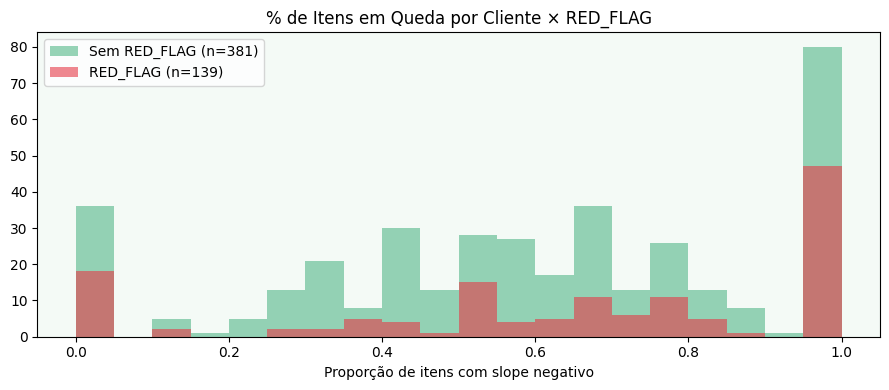


Top 20 clientes com maior queda de portfólio:


,CLIENTE,NOME,RED_FLAG,categoria_cliente,meses_sumido,slope_medio,pct_itens_queda,n_itens
0,65,INSTITUTO DE CIRURG E GAST PROF JOSE G P COELH...,True,alto,37,-1.450000,1.000000,2
1,654,MDM CLINICAS INTEGRADAS LTDA ...,True,alto,15,-1.321429,1.000000,1
2,21,ONCOBIO SERVICOS DE SAUDE SA ...,True,premium,34,-0.838655,0.823529,17
3,873,PLASTIC CARE CLINICA DE CIRURGIA PLASTICA EIRE...,False,baixo,1,-0.750000,1.000000,2
4,1216,HOSPITAL RUI MARINHO ...,False,premium,0,-0.749797,0.670588,85
5,414,MONALISY APARECIDA RODRIGUES SILVA ...,False,baixo,3,-0.500000,1.000000,1
6,899,CAIAFFA SERVICOS MEDICOS LTDA ...,True,baixo,7,-0.500000,1.000000,1
7,1055,INSTITUTO DRA NATHALLIA CHAVES LTDA ...,True,baixo,23,-0.500000,1.000000,1
8,1629,GABRIELA EVARISTO DE OLIVEIRA ...,False,baixo,0,-0.500000,1.000000,1
9,169,CENTRO ONCO. DR. OCACYR DE SIQUEIRA ...,False,baixo,28,-0.500000,1.000000,1


In [ ]:
# Carregar mapa de nomes (df_master usa CODIGO como chave)
nome_map = (
    pd.read_parquet("data/processed/df_master.parquet")[["CODIGO", "NOME"]]
    .drop_duplicates()
    .rename(columns={"CODIGO": "CLIENTE"})
)

meses_map = cliente_fidelidade.set_index("CLIENTE")[["meses_sumido"]]

# Clientes com maior queda de portfólio (slope médio mais negativo)
clientes_queda = (
    cliente_item_tendencia[cliente_item_tendencia["n_meses_ativo"] >= 3]
    .groupby(["CLIENTE", "RED_FLAG", "categoria_cliente"])
    .agg(
        slope_medio=("tendencia_slope", "mean"),
        n_itens=("SERVICO", "count"),
        n_itens_queda=("tendencia_slope", lambda x: (x < 0).sum()),
    )
    .reset_index()
)
clientes_queda["pct_itens_queda"] = clientes_queda["n_itens_queda"] / clientes_queda["n_itens"]
clientes_queda = (
    clientes_queda
    .merge(nome_map, on="CLIENTE", how="left")
    .join(meses_map, on="CLIENTE")
)

print("=== Proporção de itens em queda × RED_FLAG ===")
print(clientes_queda.groupby("RED_FLAG")["pct_itens_queda"].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
for flag, label, color in [
    (False, "Sem RED_FLAG", "#52b788"),
    (True,  "RED_FLAG",     "#e63946"),
]:
    data = clientes_queda[clientes_queda["RED_FLAG"] == flag]["pct_itens_queda"]
    ax.hist(data, bins=20, alpha=0.6, label=f"{label} (n={len(data)})", color=color)

ax.set_title("% de Itens em Queda por Cliente × RED_FLAG")
ax.set_xlabel("Proporção de itens com slope negativo")
ax.legend()
ax.set_facecolor("#f4faf6")
plt.tight_layout()
plt.show()

# Top 20 clientes com maior queda (slope médio mais negativo)
print("\nTop 20 clientes com maior queda de portfólio:")
display(
    clientes_queda
    .sort_values("slope_medio")
    .head(20)[["CLIENTE", "NOME", "RED_FLAG", "categoria_cliente", "meses_sumido", "slope_medio", "pct_itens_queda", "n_itens"]]
    .reset_index(drop=True)
)


---
## Seção 9 — Salvar Output

Salvamos `cliente_item_tendencia` em parquet para join posterior com `cliente_mes` no notebook de modelagem (`03_base_master.ipynb`).

In [ ]:
cliente_item_tendencia.to_parquet(
    "data/processed/cliente_item_tendencia.parquet", index=False
)

print("=== Salvo ===")
print(f"  data/processed/cliente_item_tendencia.parquet")
print(f"  Shape: {cliente_item_tendencia.shape}")
print(f"  Colunas: {list(cliente_item_tendencia.columns)}")

=== Salvo ===
  data/processed/cliente_item_tendencia.parquet
  Shape: (12967, 9)
  Colunas: ['CLIENTE', 'SERVICO', 'var_pct_ultimo', 'qtd_ultimo_mes', 'qtd_media', 'n_meses_ativo', 'tendencia_slope', 'RED_FLAG', 'categoria_cliente']
